<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/NB1_Sesion1_Ejemplo_Base_Estadistica_Descriptiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 4 · Estadística Aplicada y Confiabilidad de Activos
## Sesión 1 — Estadística descriptiva y distribución de fallas

Programa de Certificación en Ciencia de Datos aplicada al Mantenimiento Predictivo

### Notebook 1 · Ejemplo base — Estadística descriptiva y ajuste de distribuciones

**Objetivo:** describir estadísticamente el tiempo entre fallas (TBF) de una **Bomba Centrífuga** y ajustar la distribución de probabilidad que mejor representa su comportamiento.


## 1. Cargar los datos

Usamos un dataset sintético de la planta metalúrgica del Módulo 2, esta vez enfocado en el **tiempo entre fallas (TBF)** de cada equipo.

In [ ]:
import numpy as np
import pandas as pd

# Conjunto de activos de la planta metalúrgica (mismo caso usado desde el Módulo 2).
# Cada equipo tiene un comportamiento de falla distinto (parámetros de Weibull reales
# que iremos "descubriendo" con estadística a lo largo de la sesión).
EQUIPOS = {
    "Bomba Centrífuga":       {"beta": 1.5, "eta": 800,  "n_fallas": 60},
    "Motor Eléctrico":        {"beta": 1.0, "eta": 1200, "n_fallas": 55},
    "Compresor de Aire":      {"beta": 0.6, "eta": 400,  "n_fallas": 70},
    "Ventilador Industrial":  {"beta": 2.2, "eta": 1000, "n_fallas": 50},
    "Transportador de Banda": {"beta": 1.1, "eta": 900,  "n_fallas": 58},
}

def generar_tbf(equipo, params, seed):
    """Genera tiempos entre fallas (TBF, en horas) para un equipo usando una Weibull."""
    rng = np.random.default_rng(seed)
    tbf = rng.weibull(params["beta"], params["n_fallas"]) * params["eta"]
    return pd.DataFrame({"equipo": equipo, "tbf_horas": tbf})

fallas = pd.concat(
    [generar_tbf(eq, p, seed=i) for i, (eq, p) in enumerate(EQUIPOS.items())],
    ignore_index=True,
)

print(len(fallas))
fallas.head()

293


,equipo,tbf_horas
0,Bomba Centrífuga,618.586257
1,Bomba Centrífuga,810.417944
2,Bomba Centrífuga,58.564017
3,Bomba Centrífuga,13.815120
4,Bomba Centrífuga,537.253044


In [ ]:
fallas['equipo'].value_counts()

,count
equipo,
Compresor de Aire,70
Bomba Centrífuga,60
Transportador de Banda,58
Motor Eléctrico,55
Ventilador Industrial,50


In [ ]:
bomba = fallas[fallas["equipo"] == "Bomba Centrífuga"]["tbf_horas"]
bomba.describe()

,tbf_horas
count,60.000000
mean,755.490501
std,521.297533
min,9.469152
25%,373.763979
50%,665.906727
75%,1060.500031
max,2658.465519


## 2. Estadística descriptiva

Calculamos medidas de tendencia central y dispersión, y las interpretamos en términos de mantenimiento.

In [ ]:
media = bomba.mean()
mediana = bomba.median()
std = bomba.std()
iqr = bomba.quantile(0.75) - bomba.quantile(0.25)

print(f"Media:     {media:.1f} h")
print(f"Mediana:   {mediana:.1f} h")
print(f"Desv. Std: {std:.1f} h")
print(f"IQR:       {iqr:.1f} h")

Media:     755.5 h
Mediana:   665.9 h
Desv. Std: 521.3 h
IQR:       686.7 h


**Interpretación:** si la media y la mediana son parecidas, el TBF de la bomba es razonablemente simétrico. Si el IQR es pequeño respecto a la media, el comportamiento es predecible; si es grande, hay alta variabilidad y un plan de mantenimiento por tiempo fijo será poco eficiente.

**Un paso más allá de la media y la dispersión:** la forma de la distribución también importa. Dos medidas adicionales nos ayudan a anticipar, antes de ajustar nada, si estamos ante un patrón de desgaste (asimetría positiva) o uno más aleatorio (cercano a cero).

In [ ]:
from scipy import stats as _stats

asimetria = _stats.skew(bomba)
curtosis = _stats.kurtosis(bomba)

print(f"Asimetría (skewness): {asimetria:.2f}")
print(f"Curtosis (exceso):    {curtosis:.2f}")

Asimetría (skewness): 1.08
Curtosis (exceso):    1.55


**Interpretación rápida:** una asimetría positiva (>0) indica una "cola" hacia la derecha — hay pocos eventos con TBF muy alto que estiran la media por encima de la mediana. Esto es típico de equipos que se desgastan: la mayoría falla en un rango similar de horas, pero algunas unidades "sobreviven" mucho más. Guarda esta idea — la vamos a confirmar (o refutar) con el ajuste de distribuciones.

## 3. Visualización: histograma y boxplot

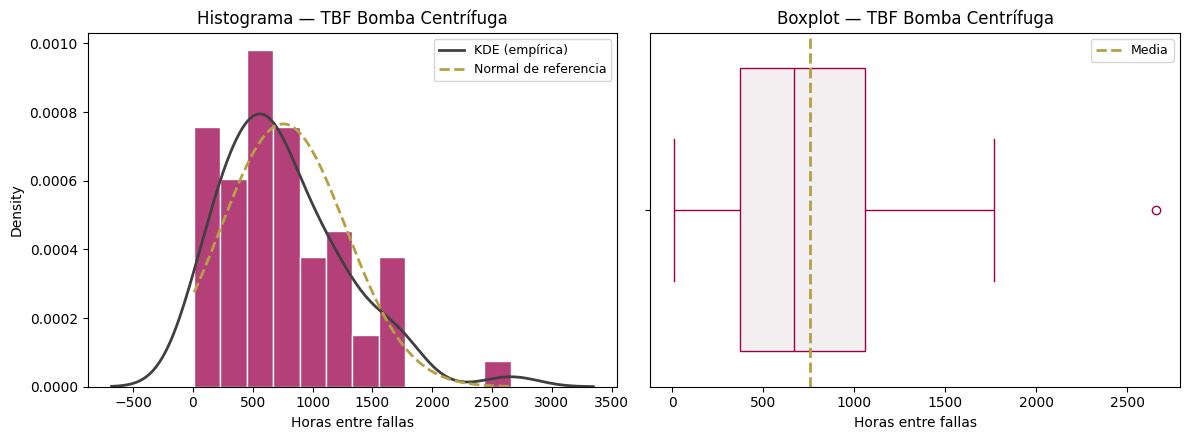

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histograma + curva KDE (densidad empírica) + curva Normal de referencia
sns.histplot(bomba, bins=12, stat="density", color="#9B004C", edgecolor="white", ax=axes[0])
sns.kdeplot(bomba, color="#404040", linewidth=2, label="KDE (empírica)", ax=axes[0])
x_ref = np.linspace(bomba.min(), bomba.max(), 200)
axes[0].plot(x_ref, norm.pdf(x_ref, media, std), color="#B5A042", linewidth=2, linestyle="--", label="Normal de referencia")
axes[0].set_title("Histograma — TBF Bomba Centrífuga")
axes[0].set_xlabel("Horas entre fallas")
axes[0].legend(fontsize=9)

# Boxplot marcando la media además de la mediana
sns.boxplot(x=bomba, ax=axes[1], color="#F4EEF1", linecolor="#9B004C")
axes[1].axvline(media, color="#B5A042", linestyle="--", linewidth=2, label="Media")
axes[1].set_title("Boxplot — TBF Bomba Centrífuga")
axes[1].set_xlabel("Horas entre fallas")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Qué agrega la curva KDE:** a diferencia de la curva Normal (que asume simetría), el KDE se adapta a la forma real de los datos sin suponer nada de antemano. Si el KDE se separa claramente de la Normal punteada, es una primera pista visual —antes incluso del ajuste formal de la sección 4— de que la Normal podría no ser la mejor candidata.

¿Hay valores atípicos (puntos fuera de los bigotes)? Anótalos — los vamos a retomar en la sesión 2 al hablar de modos de falla.

### Un vistazo comparativo: los 5 equipos a la vez

Antes de enfocarnos solo en la bomba, vale la pena ver cómo se compara contra el resto de la flota — el mismo tipo de comparación por categoría que usarás en el Notebook 3, pero aquí solo para explorar.

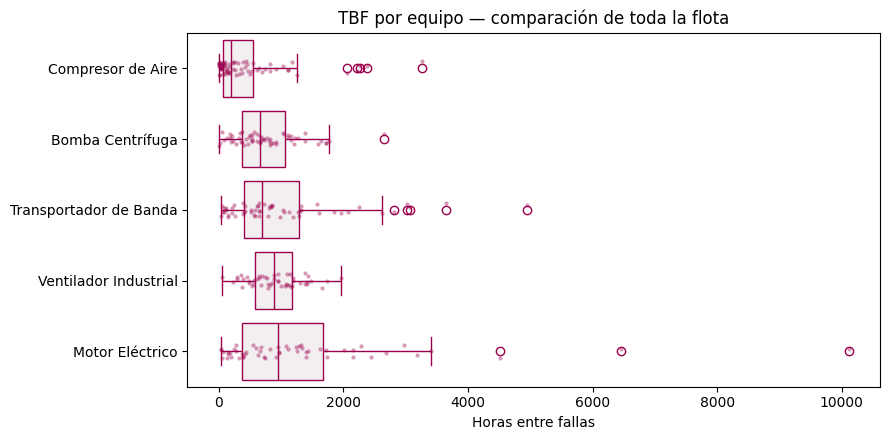

In [ ]:
plt.figure(figsize=(9, 4.5))
orden = fallas.groupby("equipo")["tbf_horas"].median().sort_values().index
sns.boxplot(data=fallas, x="tbf_horas", y="equipo", order=orden, color="#F4EEF1", linecolor="#9B004C")
sns.stripplot(data=fallas, x="tbf_horas", y="equipo", order=orden, color="#9B004C", size=3, alpha=0.4)
plt.title("TBF por equipo — comparación de toda la flota")
plt.xlabel("Horas entre fallas")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Lectura:** el equipo con la caja más ancha (mayor IQR) es el menos predecible; el que tiene la mediana más baja es el que falla con mayor frecuencia. Guarda estas observaciones — son exactamente el punto de partida de la tarea del Notebook 3.

## 4. Ajuste de distribuciones

Probamos tres distribuciones candidatas (Normal, Exponencial, Weibull) y comparamos qué tan bien se ajustan a los datos reales con la prueba de Kolmogorov-Smirnov (KS).

In [ ]:
from scipy import stats

candidatas = {
    "Normal": stats.norm,
    "Exponencial": stats.expon,
    "Weibull": stats.weibull_min,
}

resultados = []
for nombre, dist in candidatas.items():
    params = dist.fit(bomba)
    ks_stat, ks_p = stats.kstest(bomba, dist.cdf, args=params)
    resultados.append({"distribución": nombre, "parámetros": params, "KS_stat": ks_stat, "KS_p_value": ks_p})

import pandas as pd
pd.DataFrame(resultados).sort_values("KS_stat")

,distribución,parámetros,KS_stat,KS_p_value
2,Weibull,"(1.506538476134311, -19.812574287159812, 857.2...",0.048971,0.997375
0,Normal,"(755.4905010695212, 516.9351338718835)",0.110325,0.427699
1,Exponencial,"(9.4691522910716, 746.0213487784496)",0.165596,0.066096


**Cómo leer la tabla:** un `KS_stat` más bajo (y un `p_value` más alto) indica mejor ajuste. Para equipos que se desgastan con el uso —como suele ser el caso de una bomba centrífuga— esperamos que **Weibull** gane, y que su parámetro de forma resulte mayor a 1.

### Visualizar el ajuste

Una tabla de estadísticos KS es útil, pero **ver** las curvas ajustadas sobre el histograma real es lo que convence (o hace dudar) de una elección. Superponemos las tres densidades candidatas sobre los datos observados.

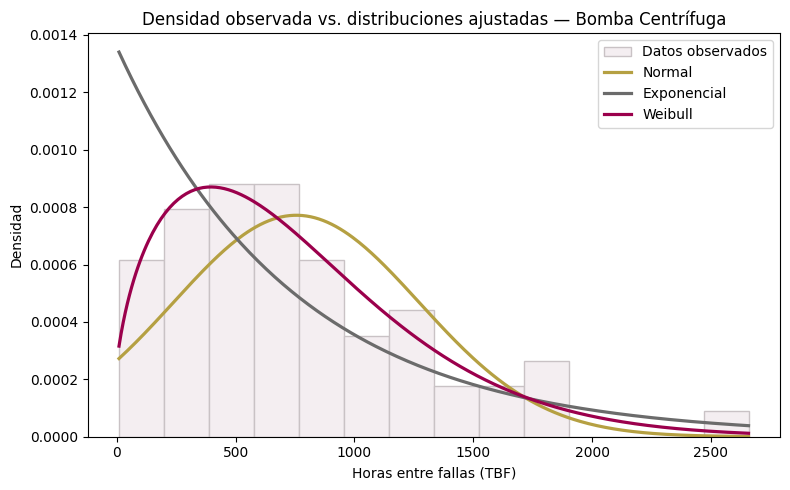

In [ ]:
x = np.linspace(bomba.min(), bomba.max(), 300)
colores = {"Normal": "#B5A042", "Exponencial": "#6B6B6B", "Weibull": "#9B004C"}

plt.figure(figsize=(8, 5))
plt.hist(bomba, bins=14, density=True, color="#F4EEF1", edgecolor="#C9C2C5", label="Datos observados")

for nombre, dist in candidatas.items():
    params = dist.fit(bomba)
    pdf = dist.pdf(x, *params)
    plt.plot(x, pdf, label=nombre, color=colores[nombre], linewidth=2.3)

plt.title("Densidad observada vs. distribuciones ajustadas — Bomba Centrífuga")
plt.xlabel("Horas entre fallas (TBF)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

**Lectura del gráfico:** la curva que mejor "abraza" la forma del histograma —sobre todo en la cola derecha— es la que mejor representa el comportamiento real del equipo. Si Weibull sigue mejor la asimetría que notamos antes (cola hacia la derecha), eso confirma visualmente lo que ya vimos en la tabla de KS.

### Gráfico Q-Q: otra forma de confirmar el ajuste

El gráfico cuantil-cuantil (Q-Q plot) compara los cuantiles de los datos reales contra los cuantiles esperados bajo la distribución ganadora. Mientras más se acerquen los puntos a la línea diagonal, mejor es el ajuste — y es más fácil de leer que comparar estadísticos KS entre sí.

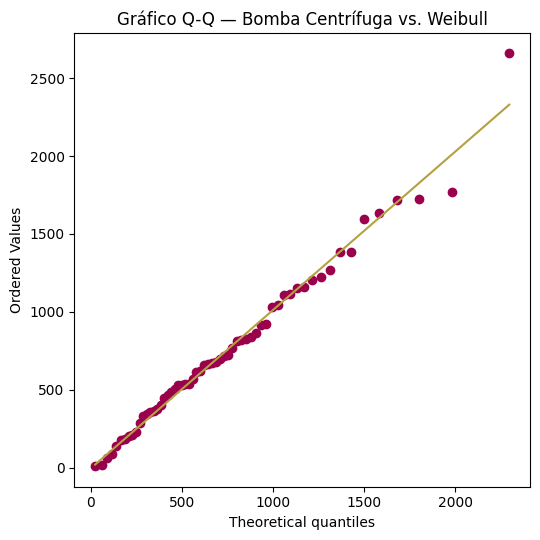

In [ ]:
mejor_dist_nombre = pd.DataFrame(resultados).sort_values("KS_stat").iloc[0]["distribución"]
mejor_dist = candidatas[mejor_dist_nombre]
params_mejor = mejor_dist.fit(bomba)

fig = plt.figure(figsize=(5.5, 5.5))
res = stats.probplot(bomba, dist=mejor_dist, sparams=params_mejor, plot=plt)
plt.gca().get_lines()[0].set_markerfacecolor("#9B004C")
plt.gca().get_lines()[0].set_markeredgecolor("#9B004C")
plt.gca().get_lines()[1].set_color("#B5A042")
plt.title(f"Gráfico Q-Q — Bomba Centrífuga vs. {mejor_dist_nombre}")
plt.tight_layout()
plt.show()

**Lectura del gráfico:** si los puntos siguen de cerca la línea dorada, la distribución ganadora describe bien los datos en todo su rango — incluidas las colas, que son justo la parte que más importa en confiabilidad (son los tiempos de falla más tempranos o más tardíos los que definen la estrategia de mantenimiento).

## 5. Conclusión

Escribe en 2-3 líneas: ¿qué distribución ajustó mejor?, ¿qué significa el parámetro de forma obtenido para la estrategia de mantenimiento de este equipo? *(La resolvemos en grupo antes de pasar al Notebook 2.)*